# 🧬 Project Overview: Binary Classification in Healthcare

This exercise applies Machine Learning principles to a real-world **binary classification** problem: predicting whether a patient's breast mass is **Benign (B)** or **Malignant (M)** based on cell characteristics. The focus is on establishing a robust **ML workflow**, including data preparation, metric selection, and model tuning.

---

## 🛠️ Ex 1.1: Data Preprocessing and Exploration

| ML/Data Science Principle | Concept | Goal |
| :--- | :--- | :--- |
| **Data Ingestion & OOP Methodology** | **Class-Based Workflow** | Encapsulating the initial steps (loading, splitting, normalizing) into a reusable class promotes good software engineering and consistency in the ML process. |
| **Data Splitting** | **Training/Testing Split** | Separating the data ensures the model's performance is evaluated on unseen data, preventing an overly optimistic assessment of generalization ability. |
| **Data Normalization/Standardization** | **Feature Scaling** | Necessary step for algorithms like k-NN that rely on **distance calculations**. Scaling features (like Radius, Smoothness) to a common range prevents features with larger numerical values from disproportionately influencing the distance metric. |
| **Exploratory Data Analysis (EDA)** | **Correlation & Pair Plots** | Visual analysis (e.g., scatter plots, histograms) to reveal **feature correlations** and the **separability** of the two target classes. This anticipates model difficulty. |

---

## 📐 Ex 1.2 - 1.5: Metric Selection and Model Evaluation

In a medical context, the choice of metric is paramount due to the high cost of misclassification.

| Task | Statistical/ML Principle | Relevance to Problem |
| :--- | :--- | :--- |
| **Ex. 1.2** | **Metric Selection (Accuracy, Precision, Recall)** | Choosing the optimal metric (**Recall** or **Precision**) based on which error is more critical: a **False Negative** (missing a malignant case) or a **False Positive** (unnecessary follow-up). **Recall** for the Malignant class is usually prioritized in medical screening to minimize missed diagnoses. |
| **Ex. 1.3** | **Hyperparameter Tuning (Distance Metric)** | **Algorithm Optimization:** Iterating through different **distance metrics** (Euclidean, Manhattan, Minkowski) for the k-Nearest Neighbors (k-NN) algorithm. The choice of metric is a critical hyperparameter that dictates how similarity between data points is measured. |
| **Ex. 1.4 & 1.5**| **Performance Visualization** | **Confusion Matrix (CM) & Classification Report:** These tools provide a comprehensive, class-by-class breakdown of the model's predictions. The normalized CM's diagonal (**Trace**) provides the **Recall** score for each class, demonstrating the direct mathematical relationship between the fundamental counts (TP, FN) and the high-level metric. |

---

## 📈 Ex 1.6: Threshold Optimization

| ML/Data Science Principle | Concept | Goal |
| :--- | :--- | :--- |
| **Receiver Operating Characteristic (ROC) Curve** | **Threshold Independence** | The ROC curve plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** across all possible classification thresholds. It provides a holistic view of the model's discriminative ability. |
| **Threshold Selection** | **Trade-off Analysis** | Discussing the **optimal threshold** involves applying domain knowledge. In a medical context, one usually accepts a slightly higher **FPR** (more follow-ups) to significantly boost the **TPR** (catch more Malignant cases), thus minimizing dangerous False Negatives. |

# ex 1

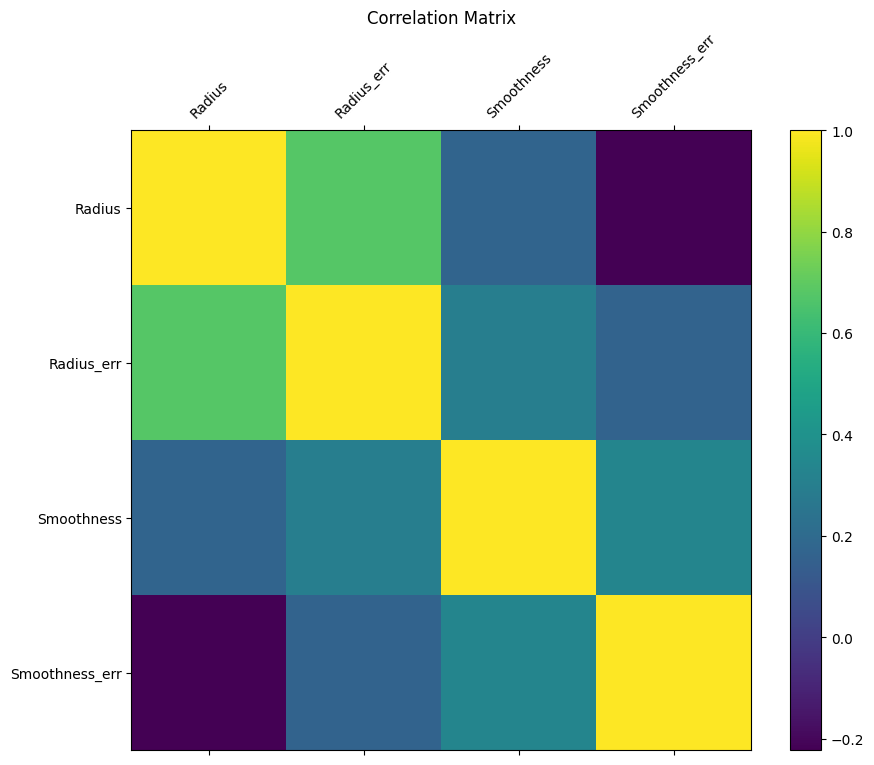

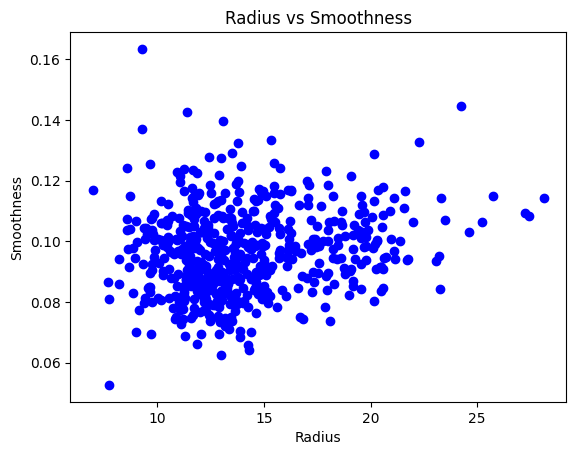

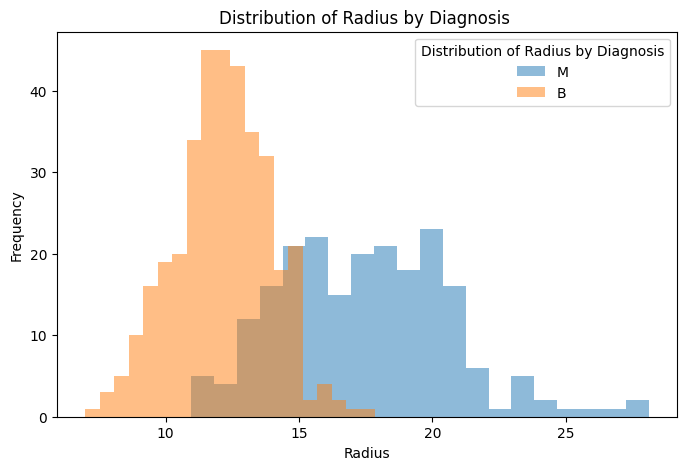

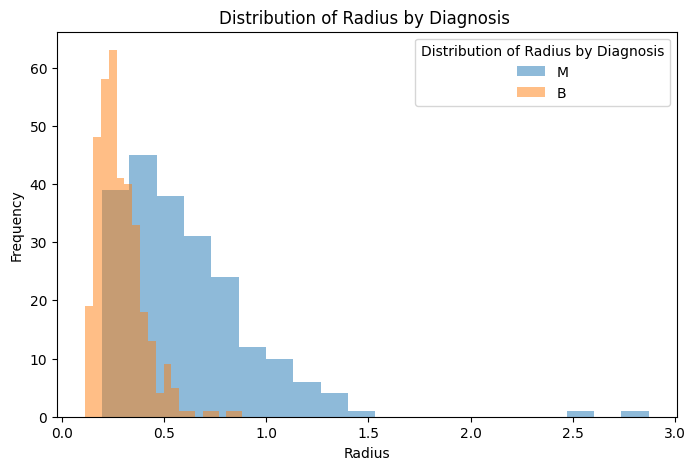

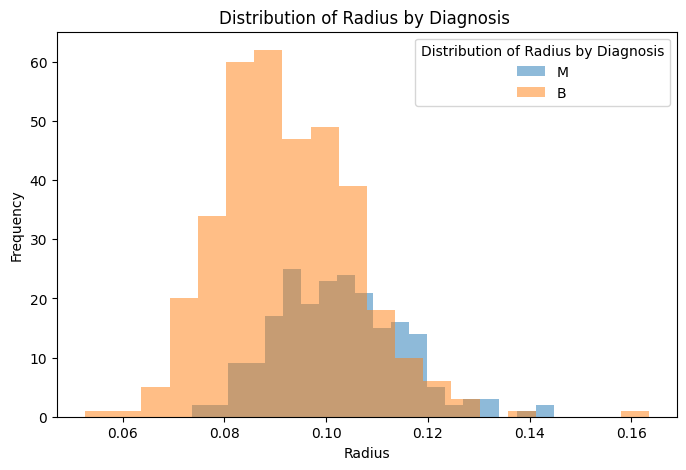

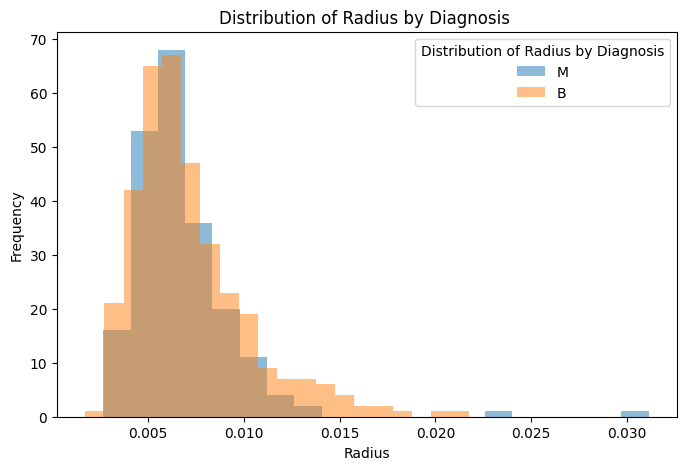

Accuracy: 0.916083916083916
              precision    recall  f1-score   support

           B       0.93      0.93      0.93        89
           M       0.89      0.89      0.89        54

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143

[[83  6]
 [ 6 48]]


In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

 

data = pd.read_csv("HW03_data.csv")

#  Data proc and model class
class DataProcessor:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        

    def split_and_normalize(self, test_size=0.25, random_state=42):
        # Data split and test
        X_train, X_test, y_train, y_test = train_test_split(self.X,  
 self.y, test_size=test_size, random_state=random_state)  


        # Normalization
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        return X_train_scaled, X_test_scaled, y_train, y_test  


    def plot_correlations(self):
        # Plot correlation matrix
        plt.figure(figsize=(10, 8))
        plt.matshow(self.X.corr(), fignum=1)
        plt.xticks(range(self.X.shape[1]), self.X.columns, rotation=45)
        plt.yticks(range(self.X.shape[1]), self.X.columns)
        plt.colorbar()
        plt.title("Correlation Matrix")
        plt.show()

    def plot_data(self, feature1, feature2,c=None):
        
        plt.scatter(self.X[feature1], self.X[feature2], c=c)
        plt.xlabel(feature1)
        plt.ylabel(feature2)
        plt.title(f"{feature1} vs {feature2}")
        plt.show()

    def train_logistic_regression(self, X_train, y_train):
        # LRM train
        model = LogisticRegression()
        model.fit(X_train, y_train)
        return model

    def evaluate_model(self,  model, X_test, y_test):
        # Model porformance
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print("Accuracy:", accuracy)  

        print(classification_report(y_test, y_pred))
        print(confusion_matrix(y_test, y_pred))  

    def plot_feature_distributions(self): 
        for column in self.X.columns:
            plt.figure(figsize=(8, 5))
            for label in self.y.unique():
                plt.hist(self.X[self.y == label][column], alpha=0.5, label=label, bins=20)
            plt.title('Distribution of Radius by Diagnosis ')
            plt.xlabel("Radius")
            plt.ylabel("Frequency")
            plt.legend(title="Distribution of Radius by Diagnosis")
            plt.show()
    

processor = DataProcessor(data.drop('Diagnosis', axis=1), data['Diagnosis'])

# Data split and normalizatoin
X_train, X_test, y_train, y_test = processor.split_and_normalize()

# Plot corr matrix - scatter and feature
processor.plot_correlations()
processor.plot_data('Radius', 'Smoothness',c="blue")  
processor.plot_feature_distributions()
# LRM train
model = processor.train_logistic_regression(X_train, y_train)

# LRM evaluation
processor.evaluate_model(model, X_test, y_test)

# ex 1.2

## Conclusion
##### With Recall we measure the positive cases that are correctly identified. In this case, it represents the percentage of true positive cancer cases that the model correctly identifies. For breast cancer classification, a high recall indicates that the model effectively identifies most of the actual cancer cases. This way we minimize false negatives (which are dangerous when it comes to cancer diagnosis)

# ex 1.3

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


data = pd.read_csv("HW03_data.csv")

# Data split and target variable
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

# disecting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  
 random_state=42)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

# distance metrics
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

# Performance evaluation
for metric in distance_metrics:
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy with {metric} distance metric: {accuracy}")



X_train shape: (455, 4)
X_test shape: (114, 4)
y_train shape: (455,)
y_test  shape: (114,)
Accuracy with euclidean distance metric: 0.9210526315789473
Accuracy with manhattan distance metric: 0.9122807017543859
Accuracy with minkowski distance metric: 0.9210526315789473


### For our problem the Euclidean metric appears to be the most optimal one 

#### * We noted that the euclidean distance metric was equal to the minkowski one this is due to the fact that the p value is 2

# ex 1.4

confusion matrix
[[68  3]
 [ 5 38]]
Classification Report:
               precision    recall  f1-score   support

           B       0.93      0.96      0.94        71
           M       0.93      0.88      0.90        43

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



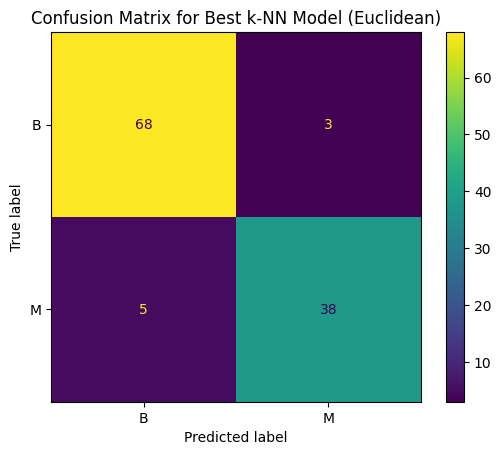

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
best_knn = KNeighborsClassifier(metric='euclidean')
best_knn.fit(X_train, y_train)
y_pred_best = best_knn.predict(X_test)


y_pred_best = best_knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
print("confusion matrix")
print(cm)
# yielding class labels 
classes = np.unique(y_train)


print('Classification Report:\n', classification_report(y_test, y_pred_best))


conf_matrix = confusion_matrix(y_test, y_pred_best, labels=classes)
ConfusionMatrixDisplay(conf_matrix, display_labels=classes).plot()

plt.title('Confusion Matrix for Best k-NN Model (Euclidean)')
plt.show()

# ex 1.5

Normalized Confusion Matrix:
[[0.95774648 0.04225352]
 [0.13953488 0.86046512]]
Trace: 1.818211595152309
Classification Report:
              precision    recall  f1-score   support

           B       0.92      0.96      0.94        71
           M       0.93      0.86      0.89        43

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



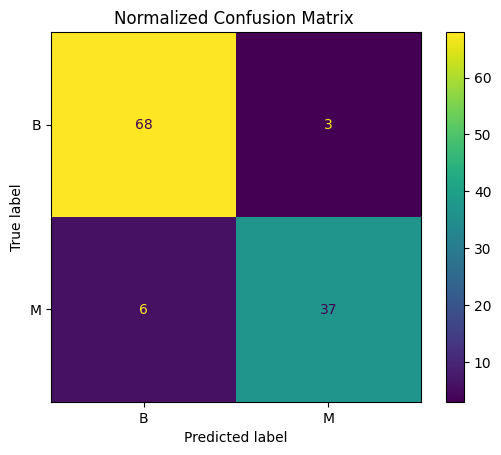

In [45]:

import numpy as np

from sklearn.metrics import confusion_matrix, classification_report



cm = confusion_matrix(y_test, y_pred)

# Normalization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  



print("Normalized Confusion Matrix:")
print(cm_normalized)

# Trace
trace = np.trace(cm_normalized)
print("Trace:", trace)


report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)
normalized_conf_matrix = confusion_matrix(y_test, y_pred, labels=classes)
ConfusionMatrixDisplay(normalized_conf_matrix, display_labels=classes).plot()

plt.title('Normalized Confusion Matrix ')
plt.show()
# to trace einai to sum twn recall scores twn class Benign kai malignant

# ex 1.6

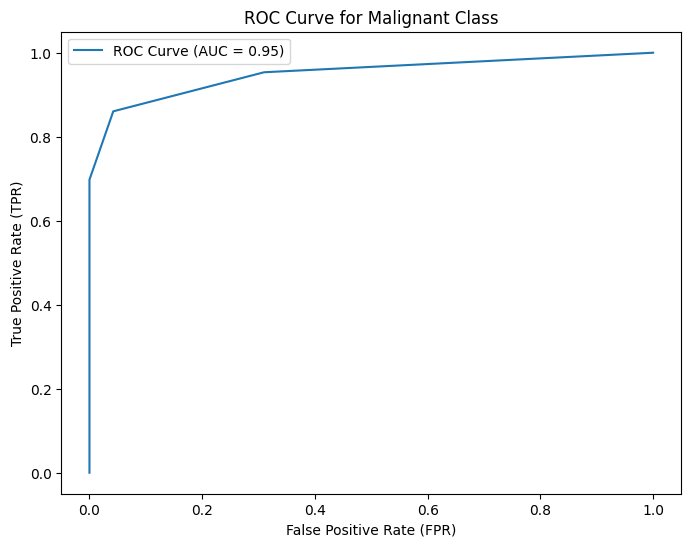

Best threshold for balance between FPR and TPR: 0.6666666666666666


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


y_test_binary = y_test.apply(lambda x: 1 if x == 'M' else 0)
y_pred_proba = knn.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_proba)
roc_auc = roc_auc_score(y_test_binary, y_pred_proba)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Malignant Class')
plt.legend()
plt.show()

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
print(f'Best threshold for balance between FPR and TPR: {best_threshold}')



## Conclusion

<p>In general the optimal threshold on the ROC curve would be chosen to ensure the best balance between 
FPR and TPR. However because in our case the data involved regards breast cancer cases,
it would be better to focus more on the effectiveness of finding a True Malignant Case (high TPR)
at the expense of having  also more false positive results by trading off the low FPR  :'(   </p>